In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
from data_utils import *
from classes import AMDModel
import contextily as cx
import matplotlib.colors as mcolors
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform

time_first = "1960"
time_last = "2015"
region = "Cyprus"
hydrobasins_region_code = "eu"
basins_iloc = [47, 48]
hybas_ids_of_interest = [2040000010]
time_array = np.ndarray(2, dtype = "datetime64[D]")
time_array[0] = np.datetime64(f"{time_first}-01-01")
time_array[-1] = np.datetime64(f"{time_last}-01-01")
date = time_array
step_size = (52, "W")
frequency = step_size[1]
length = step_size[0]

basins = gpd.read_file(f"../data/hybas_{hydrobasins_region_code}_lev04/hybas_{hydrobasins_region_code}_lev04_v1c.shp")

matching_rows = basins[basins["HYBAS_ID"].isin(hybas_ids_of_interest)]
if matching_rows.empty:
    print("No matching HYBAS_ID found.")
    print("Sample HYBAS_ID values:", basins["HYBAS_ID"].head(20).tolist())
    raise ValueError(f"HYBAS_ID not found: {hybas_ids_of_interest}")

iloc_indices = matching_rows.index.tolist()
iloc_tuple = tuple(iloc_indices)
aoi = basins.iloc[iloc_indices[0]:iloc_indices[-1] + 1]
basins_iloc[0] = iloc_indices[0]
basins_iloc[1] = iloc_indices[-1] + 1
aoi = basins.iloc[basins_iloc[0]: basins_iloc[1]]
from shapely.geometry import box

# define Cyprus bounding box (minx, miny, maxx, maxy)
cyprus_bbox = box(32.3, 34.6, 34.6, 35.7)

# clip the AOI to Cyprus only
aoi = gpd.clip(aoi, cyprus_bbox)
flo_one_qav = xr.open_dataset(flo1k_path_qav)
flo_one_qma = xr.open_dataset(flo1k_path_qma)
flo_one_qmi = xr.open_dataset(flo1k_path_qmi)
basins = gpd.read_file(basins_path)

if aoi is None:
        aoi = basins.iloc[basins_iloc[0]:basins_iloc[1]]
aoi_lat = [float(aoi.total_bounds[1]), float(aoi.total_bounds[3])]
aoi_lon = [float(aoi.total_bounds[0]), float(aoi.total_bounds[2])]

if isinstance(date, np.datetime64):
    flo_qav = flo_one_qav["qav"].sel(time = date,
                            lon = slice(aoi_lon[0], aoi_lon[1]),
                            lat = slice(aoi_lat[0], aoi_lat[1]))
    flo_min = flo_one_qmi["qmi"].sel(time = date,
                        lon = slice(aoi_lon[0], aoi_lon[1]),
                        lat = slice(aoi_lat[0], aoi_lat[1]))
    flo_max = flo_one_qma["qma"].sel(time = date,
                        lon = slice(aoi_lon[0], aoi_lon[1]),
                        lat = slice(aoi_lat[0], aoi_lat[1]))
elif isinstance(date, np.ndarray):
        flo_qav = flo_one_qav["qav"].sel(time = slice(date[0], date[-1]),
                        lon = slice(aoi_lon[0], aoi_lon[1]),
                        lat = slice(aoi_lat[0], aoi_lat[1]))
        flo_min = flo_one_qmi["qmi"].sel(time = slice(date[0], date[-1]),
                lon = slice(aoi_lon[0], aoi_lon[1]),
                lat = slice(aoi_lat[0], aoi_lat[1]))
        flo_max = flo_one_qma["qma"].sel(time = slice(date[0], date[-1]),
                lon = slice(aoi_lon[0], aoi_lon[1]),
                lat = slice(aoi_lat[0], aoi_lat[1]))
        
flo_aoi_date = xr.merge([flo_qav, flo_min, flo_max])

flo_aoi_date.rio.write_crs(aoi.crs, inplace = True)
flo_aoi_date = flo_aoi_date.rio.clip(aoi.geometry, aoi.crs)

start = flo_aoi_date.time.values[0]
n_years = len(flo_aoi_date.time)
date_range = pd.date_range(start, periods=n_years * length, freq=frequency)

Qav_repeated = np.repeat(flo_aoi_date["qav"].values, length, axis=0)
Qmi_repeated = np.repeat(flo_aoi_date["qmi"].values, length, axis=0)
Qma_repeated = np.repeat(flo_aoi_date["qma"].values, length, axis=0)

Qav_new = xr.DataArray(
    Qav_repeated,
    dims=["time", "lat", "lon"],
    coords={
        "time": date_range,
        "lat": flo_aoi_date.lat,
        "lon": flo_aoi_date.lon,
    },
    attrs={
        "units": "m3/s",
        "description": f"annual average streamflow"
    }
)

Qmi_new = xr.DataArray(
    Qmi_repeated,
    dims=["time", "lat", "lon"],
    coords={
        "time": date_range,
        "lat": flo_aoi_date.lat,
        "lon": flo_aoi_date.lon,
    },
    attrs={
        "units": "m3/s",
        "description": f"annual minimum streamflow"
    }
)

Qma_new = xr.DataArray(
    Qma_repeated,
    dims=["time", "lat", "lon"],
    coords={
        "time": date_range,
        "lat": flo_aoi_date.lat,
        "lon": flo_aoi_date.lon,
    },
    attrs={
        "units": "m3/s",
        "description": f"annual maximum streamflow"
    }
)


flo = xr.merge([Qav_new, Qmi_new, Qma_new])
lats = flo.lat 
lons = flo.lon
time_anchors = []
n_years = len(flo.time.values)
# make time anchors
for i in range(n_years):
       offset = i * 52
       time_anchors.extend([offset + 2, offset + 15, offset + 28, offset + 41])

time_anchors.append(n_years * 52 + 2)
time_anchors = np.array(time_anchors)

y_0 = xr.where(flo["qmi"].lat >= 0, flo["qma"], flo["qmi"])
y_2 = xr.where(flo["qmi"].lat >= 0, flo["qmi"], flo["qma"])
y_1 = flo["qav"]
y_3 = flo["qav"]

y_stacked = xr.concat([y_0, y_1, y_2, y_3], dim = "season")
y_stacked = y_stacked.transpose("year", "season", "lat", "lon")

y_flat = y_stacked.values.reshape(n_years * 4, len(lats), len(lons))

wrap_y = np.expand_dims(y_0.isel(year=-1).values, axis = 0)

y_final = np.concatenate([y_flat, wrap_y], axis = 0)

slopes = np.zeros_like(y_final)

odd_indices = np.arange(1, len(time_anchors), 2)

dy = y_final[odd_indices + 1] - y_final[odd_indices - 1]
dx = time_anchors[odd_indices + 1] - time_anchors[odd_indices - 1]

dx = dx.reshape(-1, 1, 1)
slopes[odd_indices] = dy / dx

total_weeks = n_years * 52
target_weeks = np.arange(1, total_weeks + 1)

spline = CubicHermiteSpline(x = time_anchors, y = y_final, dydx = slopes)
predicted_weekly = spline(target_weeks)

predictied_weekly = np.clip(predicted_weekly, 0, None)

time_index = pd.date_range(start=f"{years[0]}-01-01", periods=total_weeks, freq="W-MON")

flo_da = xr.DataArray(
    predicted_weekly,
    coords={
        'time': time_index,
        'lat': lats,
        'lon': lons
    },
    dims=['time', 'lat', 'lon'],
    name="Q"
)




Setting up dummy spatial and temporal datasets...
Running corrected Hermite Splining...
Splining complete!
Output shape: (2912, 10, 10) (Weeks: 2912, Lats: 10, Lons: 10)
Plotting validation chart for Cyprus coordinate...


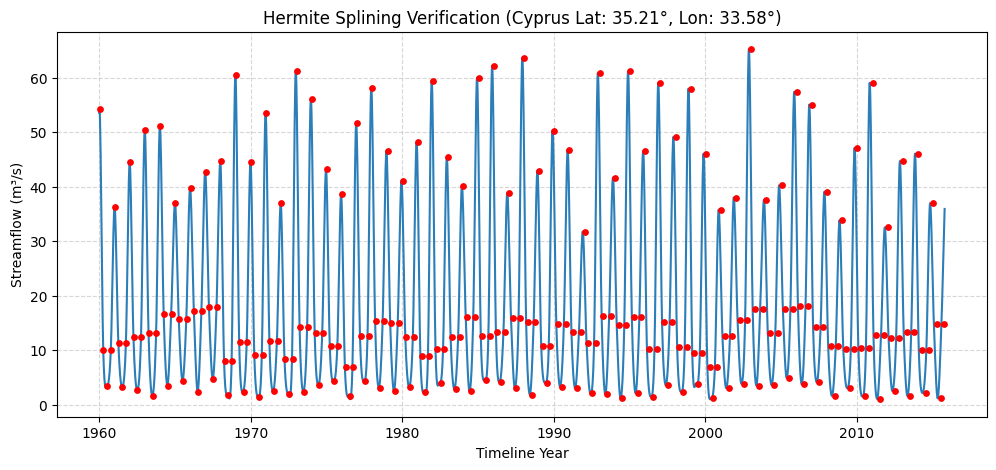

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
from scipy.interpolate import CubicHermiteSpline
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP DUMMY DATA (Simulating Cyprus & FLO1K)
# ==========================================
print("Setting up dummy spatial and temporal datasets...")

time_first = "1960"
time_last = "2015"
years = pd.date_range(start=f"{time_first}-01-01", end=f"{time_last}-01-01", freq="YS")
n_years = len(years)

# Create Cyprus bounding box bounding coordinates
minx, miny, maxx, maxy = 32.3, 34.6, 34.6, 35.7
lat_coords = np.linspace(miny, maxy, 10)
lon_coords = np.linspace(minx, maxx, 10)

# Simulate annual streamflow matrices (time, lat, lon)
shape = (n_years, len(lat_coords), len(lon_coords))
dummy_qmi = np.random.uniform(1, 5, shape)
dummy_qav = dummy_qmi + np.random.uniform(5, 15, shape)
dummy_qma = dummy_qav + np.random.uniform(20, 50, shape)

# Assemble into Xarray datasets to mimic your flo_one_qmi, flo_one_qma, flo_one_qav
flo_one_qmi = xr.Dataset({"qmi": (["time", "lat", "lon"], dummy_qmi)}, coords={"time": years, "lat": lat_coords, "lon": lon_coords})
flo_one_qav = xr.Dataset({"qav": (["time", "lat", "lon"], dummy_qav)}, coords={"time": years, "lat": lat_coords, "lon": lon_coords})
flo_one_qma = xr.Dataset({"qma": (["time", "lat", "lon"], dummy_qma)}, coords={"time": years, "lat": lat_coords, "lon": lon_coords})

# Merge datasets mimicking your code
flo_aoi_date = xr.merge([flo_one_qav["qav"], flo_one_qmi["qmi"], flo_one_qma["qma"]])

# ==========================================
# 2. THE CORRECTED SPLINING PIPELINE
# ==========================================
print("Running corrected Hermite Splining...")

lats = flo_aoi_date.lat 
lons = flo_aoi_date.lon

# Create continuous time anchors spanning the series (4 seasonal anchors per year)
time_anchors = []
for i in range(n_years):
    offset = i * 52
    # Week 2 (Peak), Week 15 (Mean), Week 28 (Trough), Week 41 (Mean)
    time_anchors.extend([offset + 2, offset + 15, offset + 28, offset + 41])

# Append the final wrap-around anchor to close the timeline smoothly
time_anchors.append(n_years * 52 + 2)
time_anchors = np.array(time_anchors)

# Hemisphere-aware baseline mapping
# If Lat >= 0 (North): winter max occurs first, summer min occurs in the middle
# If Lat < 0 (South): summer min occurs first, winter max occurs in the middle
y_0 = xr.where(flo_aoi_date["qmi"].lat >= 0, flo_aoi_date["qma"], flo_aoi_date["qmi"])
y_2 = xr.where(flo_aoi_date["qmi"].lat >= 0, flo_aoi_date["qmi"], flo_aoi_date["qma"])
y_1 = flo_aoi_date["qav"]
y_3 = flo_aoi_date["qav"]

# Stack seasonal coordinates sequentially
# Note: Stack along a new 'season' coordinate to avoid renaming issues
y_stacked = xr.concat([y_0, y_1, y_2, y_3], dim="season")

# Transpose securely (switching seasonal dimensions first)
# Current dimensions of y_stacked: (season, time, lat, lon) -> we want (time, season, lat, lon)
y_stacked = y_stacked.transpose("time", "season", "lat", "lon")

# Flatten the timeline securely (N_years * 4, lat, lon)
y_flat = y_stacked.values.reshape(n_years * 4, len(lats), len(lons))

# Grab the final wrap-around value
wrap_y = np.expand_dims(y_0.isel(time=-1).values, axis=0)

# Concatenate wrap-around array to close the boundary condition securely
y_final = np.concatenate([y_flat, wrap_y], axis=0)

# Calculate Hermite Slopes (dydx) across the multi-year boundary
slopes = np.zeros_like(y_final)
odd_indices = np.arange(1, len(time_anchors), 2)

dy = y_final[odd_indices + 1] - y_final[odd_indices - 1]
dx = time_anchors[odd_indices + 1] - time_anchors[odd_indices - 1]

# Broadcast dx to 3D to match Y matrix divisions
dx = dx.reshape(-1, 1, 1)
slopes[odd_indices] = dy / dx

# Build the 52-week per year target prediction timeline
total_weeks = n_years * 52
target_weeks = np.arange(1, total_weeks + 1)

# Fit Hermite splining across all spatial axes simultaneously
spline = CubicHermiteSpline(x=time_anchors, y=y_final, dydx=slopes)
predicted_weekly = spline(target_weeks)

# Apply Hydrological Failsafe to protect against negative flows
predicted_weekly = np.clip(predicted_weekly, 0, None)

# Generate a continuous Weekly pandas date index starting at time_first
time_index = pd.date_range(start=f"{time_first}-01-01", periods=total_weeks, freq="W-MON")

# Construct the final DataArray
flo_da = xr.DataArray(
    predicted_weekly,
    coords={
        'time': time_index,
        'lat': lats,
        'lon': lons
    },
    dims=['time', 'lat', 'lon'],
    name="Q"
)

print("Splining complete!")
print(f"Output shape: {flo_da.shape} (Weeks: {total_weeks}, Lats: {len(lats)}, Lons: {len(lons)})")

# ==========================================
# 3. VISUALIZATION AND VERIFICATION
# ==========================================
print("Plotting validation chart for Cyprus coordinate...")
plt.figure(figsize=(12, 5))

# Pick a single pixel in Cyprus to verify the interpolation path
lat_idx, lon_idx = 5, 5
pixel_series = flo_da.isel(lat=lat_idx, lon=lon_idx)

# Plot interpolated continuous weekly dataset
plt.plot(flo_da.time, pixel_series, label="Splined Weekly Streamflow (Q)", color='#1f77b4', alpha=0.95)

# Extract and plot the original annual inputs as comparison anchors
# We map the inputs to the months they represent on the real calendar timeline
anchor_times = []
anchor_vals = []
for idx, yr in enumerate(years):
    y_val = yr.year
    # Winter Max (Jan), Spring Mean (Apr), Summer Min (Jul), Autumn Mean (Oct)
    anchor_times.extend([
        pd.Timestamp(f"{y_val}-01-15"),
        pd.Timestamp(f"{y_val}-04-15"),
        pd.Timestamp(f"{y_val}-07-15"),
        pd.Timestamp(f"{y_val}-10-15")
    ])
    anchor_vals.extend([
        flo_aoi_date["qma"].isel(time=idx, lat=lat_idx, lon=lon_idx).values,
        flo_aoi_date["qav"].isel(time=idx, lat=lat_idx, lon=lon_idx).values,
        flo_aoi_date["qmi"].isel(time=idx, lat=lat_idx, lon=lon_idx).values,
        flo_aoi_date["qav"].isel(time=idx, lat=lat_idx, lon=lon_idx).values,
    ])

plt.scatter(anchor_times, anchor_vals, color='red', s=15, zorder=5, label="Original Input Anchors")

# Format the visualizer
plt.title(f"Hermite Splining Verification (Cyprus Lat: {lats[lat_idx].values:.2f}°, Lon: {lons[lon_idx].values:.2f}°)")
plt.xlabel("Timeline Year")
plt.ylabel("Streamflow (m³/s)")
plt.grid(True, linestyle="--", alpha=0.5)